In [189]:

import torch
device = torch.device("xpu" if torch.xpu.is_available() else "cpu")
print(f"Using: {device}")

Using: xpu


In [190]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [191]:
words = open('names.txt','r').read().splitlines()

In [192]:
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [193]:
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [194]:
block_size = 3
X,Y = [],[]

for w in words:
    context = [0]*block_size
    #print(w)
    for ch in w + '.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[ix] for ix in context),'----->',itos[ix])
        context=context[1:]+[ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

In [195]:
def build_dataset(words):
    block_size = 3#how many letters we take to print the next
    X,Y = [],[]

    for w in words:
        context = [0]*block_size
        #print(w)
        for ch in w + '.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[ix] for ix in context),'----->',itos[ix])
            context=context[1:]+[ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)

    return X,Y
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

torch.Size([182579, 3]) torch.Size([182579])
torch.Size([22695, 3]) torch.Size([22695])
torch.Size([22866, 3]) torch.Size([22866])


In [196]:
#Xtr = Xtr.to(device)
#Ytr = Ytr.to(device)

In [197]:
C = torch.randn((27,2))

In [198]:
emb = C[X]
emb

tensor([[[-0.6957,  2.4370],
         [-0.6957,  2.4370],
         [-0.6957,  2.4370]],

        [[-0.6957,  2.4370],
         [-0.6957,  2.4370],
         [ 1.1734,  1.6030]],

        [[-0.6957,  2.4370],
         [ 1.1734,  1.6030],
         [-1.9314, -0.7770]],

        ...,

        [[-0.9997,  0.2085],
         [ 1.3567,  0.3057],
         [-0.6196,  1.2955]],

        [[ 1.3567,  0.3057],
         [-0.6196,  1.2955],
         [ 0.1753, -1.2685]],

        [[-0.6196,  1.2955],
         [ 0.1753, -1.2685],
         [ 1.6841,  0.2018]]])

In [199]:
W1 = torch.randn(6,100)
B1 = torch.randn(100) #assumeing hundred neurons and 6 inputs cuz emb shape = 32 2 3 (2x3 = 6)

In [200]:
h = torch.tanh(emb.view(-1,6)@W1 + B1)#-1 keeps the other dimensions here it would be emb.shape[0]==32

In [201]:
h.shape

torch.Size([228140, 100])

In [202]:
W2 = torch.randn((100,27))
B2 = torch.randn(27)

In [203]:
logits = h@W2 + B2

In [204]:
#counts = logits.exp()
#probs = counts/counts.sum(1,keepdim=True)
#loss = -probs[torch.arange(32),Y].log().mean() highly inefficient form of cross-entropy function as they create new tensors

In [205]:
X.shape,X.dtype,Y.shape,Y.dtype

(torch.Size([228140, 3]), torch.int64, torch.Size([228140]), torch.int64)

In [233]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10),generator=g)#.to(device)
W1 = torch.randn(30,200,generator=g)*0.01#.to(device)
B1 = torch.randn(200,generator= g)*0.00#.to(device)
W2 = torch.randn((200,27),generator=g)*0.01#.to(device)
B2 = torch.randn(27,generator=g)#.to(device)
parameters = [C,W1,B1,W2,B2]

In [234]:
for p in parameters:
    p.requires_grad=True

In [235]:
sum(p.nelement() for p in parameters)

11897

In [236]:
lossi,stepi =[],[]

In [237]:
for i in range(200000):
    ix = torch.randint(0,Xtr.shape[0],(32,)) #minibatch
    #forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + B1)
    logits = h@W2 + B2
    loss = F.cross_entropy(logits,Ytr[ix])
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #updation
    lr = 0.1 if i<100000 else 0.01
    for p in parameters:
        p.data += -lr*p.grad
    lossi.append(loss.item())
    stepi.append(i)
print(loss.item())

2.4215612411499023


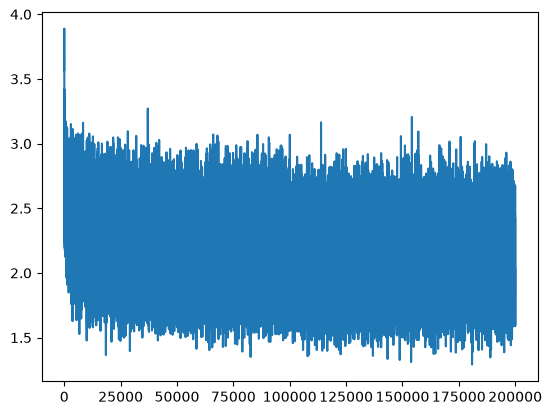

In [238]:
plt.plot(stepi,lossi)

In [239]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + B1)
logits = h@W2 + B2
F.cross_entropy(logits,Ydev)

tensor(2.1391, grad_fn=<NllLossBackward0>)

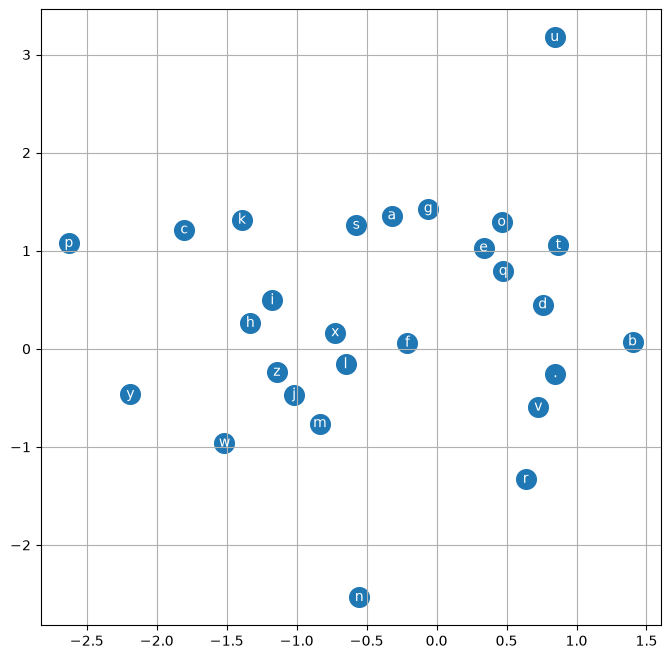

In [240]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [242]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + B1)
      logits = h @ W2 + B2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carmah.
amilli.
khi.
mili.
taty.
halaysie.
rahnen.
delynn.
jareei.
nellara.
chaiir.
kaleigh.
ham.
jock.
quintis.
lilea.
jadiquinterridearyxi.
jace.
pirra.
med.
